**Name:** Diana Valverde

### `PHYTON - Proyect 1.`
nyc open data - 311 data

In [17]:
import pandas as pd
url = "https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/311_Service_Requests_from_2019May.csv"
df = pd.read_csv(url)

/tmp/ipykernel_2087/1462044036.py:3: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url)


In [2]:
df.head(2)
#show me only the first 2 rows

,Unique Key,Created Date,Closed Date,Agency,Complaint Type,Location Type,Incident Zip,Incident Address,Street Name,Address Type,...,Landmark,Facility Type,Status,Due Date,Resolution Description,BBL,Borough,Latitude,Longitude,Location
0,42680103,5/1/2019 0:00,5/16/2019 21:45,DEP,Water System,NaN,11420.0,127-16 111 AVENUE,111 AVENUE,ADDRESS,...,NaN,NaN,Closed,NaN,The Department of Environment Protection inspe...,4.116320e+09,QUEENS,40.682565,-73.814060,"(40.682565064146196, -73.81406015056832)"
1,42530481,5/1/2019 0:00,5/2/2019 0:00,DOHMH,Food Poisoning,Restaurant/Bar/Deli/Bakery,10011.0,207 WEST 14 STREET,WEST 14 STREET,ADDRESS,...,NaN,NaN,Closed,5/15/2019 22:17,Callers should contact the DOHMH Foodborne Ill...,1.007640e+09,MANHATTAN,40.738791,-74.000224,"(40.738790792032844, -74.00022373020307)"


How many rows and columns are there in this dataset?

In [3]:
df.shape
#(rows,columns)

(69637, 21)

What’s the time range of this dataset?

In [4]:
df['Created Date'].min()

'5/1/2019 0:00'

In [5]:
df['Created Date'].max()

'5/9/2019 9:59'

In [6]:
print("Start date:", df['Created Date'].min())
print("End date:", df['Created Date'].max())

Start date: 5/1/2019 0:00
End date: 5/9/2019 9:59


What are some relevant summary statistics?

In [7]:
df.describe()
#summary statistics for numerical columns.

,Unique Key,BBL,Latitude,Longitude
count,6.963700e+04,5.570200e+04,65634.000000,65634.000000
mean,4.260307e+07,2.869652e+09,40.723149,-73.924517
std,5.269818e+04,1.184250e+09,0.083621,0.085089
min,4.251278e+07,0.000000e+00,40.500025,-74.252279
25%,4.258004e+07,2.030690e+09,40.664461,-73.972161
50%,4.260019e+07,3.034830e+09,40.716443,-73.929758
75%,4.262095e+07,4.023330e+09,40.780783,-73.874064
max,4.297343e+07,5.080480e+09,40.912869,-73.700597


In [8]:
df['Complaint Type'].value_counts()
#the most common type of complaints.

,count
Complaint Type,
Noise - Residential,5838
Request Large Bulky Item Collection,5301
Illegal Parking,5257
Blocked Driveway,3391
Street Condition,3080
...,...
Highway Sign - Damaged,1
Taxi Compliment,1
Illegal Fireworks,1


In [9]:
df['Borough'].value_counts()
#most common requests by borough.

,count
Borough,
BROOKLYN,22247
QUEENS,18623
MANHATTAN,13133
BRONX,10925
STATEN ISLAND,3848
Unspecified,861


In [10]:
df.isnull().sum()
#number of missing values there are in each column.

,0
Unique Key,0
Created Date,0
Closed Date,5011
Agency,0
Complaint Type,0
Location Type,15659
Incident Zip,2248
Incident Address,10604
Street Name,10605
Address Type,1330


Create 2-3 visualizations from this dataset.

<Axes: title={'center': 'Complaint Types by Borough'}, xlabel='Complaint Type', ylabel='Number of Requests'>

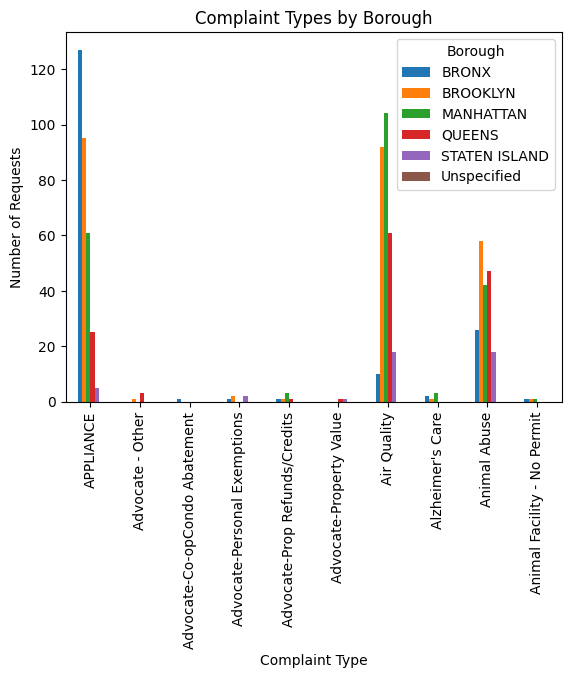

In [11]:
complaints_borough = pd.crosstab(df['Complaint Type'], df['Borough'])

complaints_borough.head(10).plot(
    kind='bar',
    title='Complaint Types by Borough',
    xlabel='Complaint Type',
    ylabel='Number of Requests'
)

#pd.crosstab // sirve para contar cuantas veces ocurre algo en relacion
#con otra cosa en este caso:(df['Complaint Type'] y df['Borough'])
#entonces estariamos preguntando cuantas quejas de cada tipo hay en cada borough?
#complaints_borough.head(10).plot // aqui solitamos solo las 10 primeras filas
#porque la tabla es muy extensa y queremos una grafica:
#.plot(
#    kind='bar' //grafica de barras

<Axes: title={'center': 'Food Poisoning Complaints by Borough'}, xlabel='Borough', ylabel='Number of Requests'>

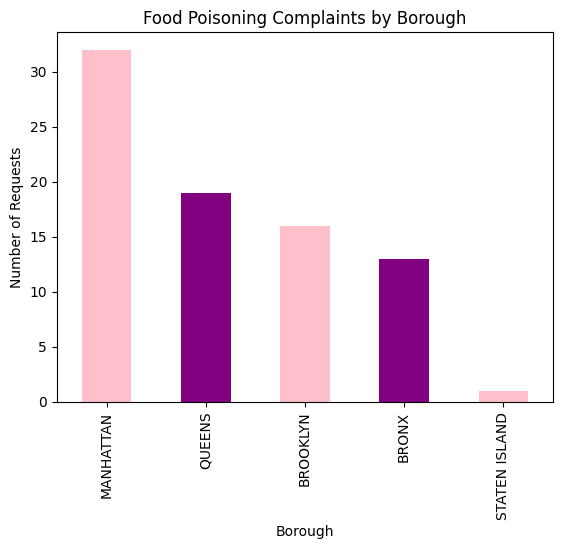

In [12]:
food = df[df['Complaint Type'] == 'Food Poisoning']
food['Borough'].value_counts().plot(
    kind='bar',
    color=['pink', 'purple'],
    title='Food Poisoning Complaints by Borough',
    xlabel='Borough',
    ylabel='Number of Requests'
)

What borough has the most complaints?

In [13]:
df['Borough'].value_counts().head(1)
#.value_counts() // cuantas veces aparece cada valor de los boroughs.
#.head(1) //dame solo el primer valor con mayor numero de veces

,count
Borough,
BROOKLYN,22247


Create a plot of counts by borough for noise complaints.

<Axes: title={'center': 'Noise Complaints by Borough'}, xlabel='Borough', ylabel='Number of Complaints'>

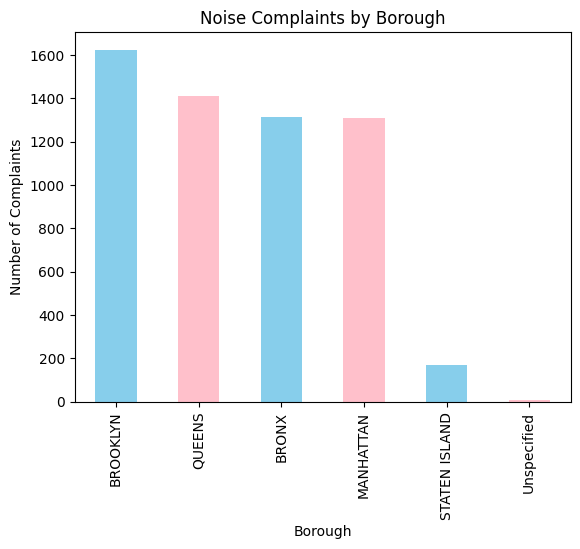

In [14]:
noise = df[df['Complaint Type'] == 'Noise - Residential']

noise['Borough'].value_counts().plot(
    kind='bar',
    color=['skyblue', 'pink'],
    title='Noise Complaints by Borough',
    xlabel='Borough',
    ylabel='Number of Complaints'
)
#df → es todo tu dataset.
#['Complaint Type'] → seleccionamos la columna donde está el tipo de queja.
#== 'Noise - Residential' → le decimos a Python: “quiero solamente las quejas que sean Noise - Residential.”
#noise = → guardamos esas quejas en una nueva variable llamada noise.
#Ahora noise contiene solo las quejas de ruido residencial.
#noise → usamos solamente las quejas de ruido.
#['Borough'] → seleccionamos la columna de borough.
#.value_counts() → contamos cuántas veces aparece cada borough.
#kind='bar' significa gráfico de barras.
#title → título del gráfico.
#xlabel → nombre del eje X.
#ylabel → nombre del eje Y.


Find one more interesting piece of information (anything).

In [26]:
#Which day of the week they recieve most complaints?
df['Created Date'] = pd.to_datetime(df['Created Date'])
df['Day'] = df['Created Date'].dt.day_name()
most_complaints = df['Day'].value_counts()
print(most_complaints)

Day
Wednesday    16598
Thursday     16099
Monday        8666
Tuesday       8472
Friday        8108
Saturday      6239
Sunday        5455
Name: count, dtype: int64


Plot Grafic

<Axes: title={'center': 'Complaints by Day of the Week'}, xlabel='Day', ylabel='Number od Complaints'>

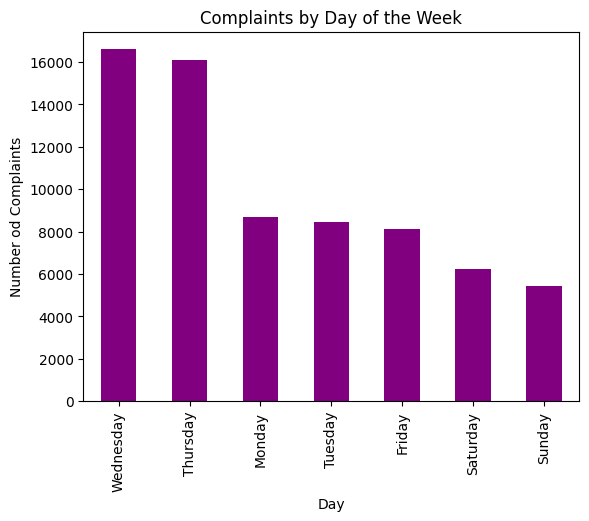

In [27]:
df['Day'].value_counts().plot(
    kind='bar',
    color='purple',
    title='Complaints by Day of the Week',
    xlabel='Day',
    ylabel='Number od Complaints'
)
